In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
train_data = train_data.drop(["Name", "Ticket", "Cabin"], axis=1)
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [3]:
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
test_data = test_data.drop(["Name", "Ticket", "Cabin"], axis=1)
test_data.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,male,34.5,0,0,7.8292,Q
1,893,3,female,47.0,1,0,7.0000,S
2,894,2,male,62.0,0,0,9.6875,Q
3,895,3,male,27.0,0,0,8.6625,S
4,896,3,female,22.0,1,1,12.2875,S


In [4]:
y = train_data["Survived"]

train_data["Age"].fillna(train_data["Age"].median())
features = ["Sex", "Embarked"]
X = pd.get_dummies(train_data, columns=features, dtype=int)
X = X.drop(["Survived"], axis=1)
X_test = pd.get_dummies(test_data, columns=features, dtype=int)

X_train, X_cv, y_train, y_cv = train_test_split(X, y, test_size=0.25, random_state=1)

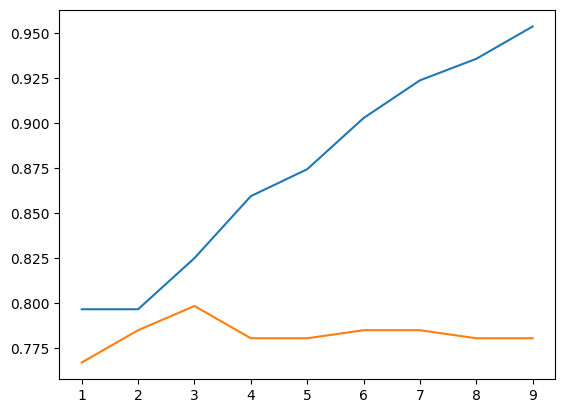

[0.7964071856287425, 0.7964071856287425, 0.8248502994011976, 0.8592814371257484, 0.874251497005988, 0.9026946107784432, 0.9236526946107785, 0.9356287425149701, 0.9535928143712575] [0.7668161434977578, 0.7847533632286996, 0.7982062780269058, 0.7802690582959642, 0.7802690582959642, 0.7847533632286996, 0.7847533632286996, 0.7802690582959642, 0.7802690582959642]


In [5]:
train_percs = []
cv_percs = []
for i in range(9):
    model = RandomForestClassifier(n_estimators=300, max_depth=i+1, random_state=1)
    model.fit(X_train, y_train)
    train_predictions = model.predict(X_train)
    cv_predictions = model.predict(X_cv)
    train_percentage = sum(y_train == train_predictions) / len(y_train == train_predictions)
    cv_percentage = sum(y_cv == cv_predictions) / len(y_cv == cv_predictions)
    train_percs.append(train_percentage)
    cv_percs.append(cv_percentage)

plt.plot([1,2,3,4,5,6,7,8,9], train_percs)
plt.plot([1,2,3,4,5,6,7,8,9], cv_percs)

plt.show()
print(train_percs, cv_percs)

In [6]:
model = RandomForestClassifier(n_estimators=300, max_depth=3, random_state=1)
model.fit(X_train, y_train)
test_predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId' : test_data.PassengerId, 'Survived' : test_predictions})
output.to_csv('submission.csv', index=False)